#### 1. Daten laden

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = pd.read_excel("intakes_outcomes_demo.xlsx")

data.head()

,age_upon_outcome,animal_id_outcome,outcome_subtype,outcome_type,sex_upon_outcome,age_upon_outcome_(days),age_upon_outcome_(years),age_upon_outcome_age_group,outcome_month,outcome_year,...,age_upon_intake_(years),age_upon_intake_age_group,intake_month,intake_year,intake_monthyear,intake_weekday,intake_hour,intake_number,time_in_shelter,time_in_shelter_days
0,10 years,A006100,NaN,Return to Owner,Neutered Male,3650,10,"(7.5, 10.0]",12,2017,...,10,"(7.5, 10.0]",12,2017,2017-12-01,Thursday,14,1,0 days 14:07:00.000000000,0.588194
1,7 years,A006100,NaN,Return to Owner,Neutered Male,2555,7,"(5.0, 7.5]",12,2014,...,7,"(5.0, 7.5]",12,2014,2014-12-01,Friday,10,2,1 days 06:14:00.000000000,1.259722
2,6 years,A006100,NaN,Return to Owner,Neutered Male,2190,6,"(5.0, 7.5]",3,2014,...,6,"(5.0, 7.5]",3,2014,2014-03-01,Friday,14,3,1 days 02:44:00.000000000,1.113889
3,10 years,A047759,Partner,Transfer,Neutered Male,3650,10,"(7.5, 10.0]",4,2014,...,10,"(7.5, 10.0]",4,2014,2014-04-01,Wednesday,15,1,4 days 23:17:00.000000000,4.970139
4,16 years,A134067,NaN,Return to Owner,Neutered Male,5840,16,"(15.0, 17.5]",11,2013,...,16,"(15.0, 17.5]",11,2013,2013-11-01,Saturday,9,1,0 days 02:52:00.000000000,0.119444


#### 2. Überblick über die Daten

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   age_upon_outcome            999 non-null    str           
 1   animal_id_outcome           999 non-null    str           
 2   outcome_subtype             251 non-null    str           
 3   outcome_type                999 non-null    str           
 4   sex_upon_outcome            999 non-null    str           
 5   age_upon_outcome_(days)     999 non-null    int64         
 6   age_upon_outcome_(years)    999 non-null    int64         
 7   age_upon_outcome_age_group  999 non-null    str           
 8   outcome_month               999 non-null    int64         
 9   outcome_year                999 non-null    int64         
 10  outcome_monthyear           999 non-null    datetime64[us]
 11  outcome_weekday             999 non-null    str           
 12  outco

#### 3. Zielvariable definieren (time_in_shelter_days)

In [17]:
data["time_in_shelter_days"].head()

0    0.588194
1    1.259722
2    1.113889
3    4.970139
4    0.119444
Name: time_in_shelter_days, dtype: float64

1.2 Auswahl des Feldes
Ich habe das Feld time_in_shelter_days als Zielvariable ausgewählt. Diese Spalte gibt an, wie viele Tage ein Tier im Tierheim verbracht hat, bevor es wieder abgegeben wurde. Ziel des Projekts ist es, diese Aufenthaltsdauer anhand verschiedener Merkmale wie Tierart (animal_type), Alter (age_upon_intake_(years)), Geschlecht oder Aufnahmeart vorherzusagen. Diese Variable eignet sich gut für Machine Learning, da die Aufenthaltsdauer stark von Eigenschaften des Tieres und der Situation bei der Aufnahme beeinflusst werden kann

#### 4. Statistische Analyse

In [11]:
data["time_in_shelter_days"].describe()

count    999.000000
mean      15.396815
std       45.420819
min        0.000694
25%        0.472917
50%        2.972222
75%        9.254514
max      641.990278
Name: time_in_shelter_days, dtype: float64

Count: 999 Tiere wurden analysiert.

Mean: Durchschnittliche Aufenthaltsdauer beträgt etwa 15,4 Tage.

Std: Die Standardabweichung von 45,4 Tagen zeigt, dass die Aufenthaltsdauer stark variieren kann.

Min: Kürzeste Aufenthaltsdauer beträgt etwa 0 Tage (sehr schnelle Abgabe).

25%: 25 % der Tiere bleiben weniger als etwa 0,47 Tage im Shelter.

50% (Median): Die Hälfte der Tiere bleibt weniger als etwa 3 Tage.

75%: 75 % der Tiere bleiben weniger als etwa 9,25 Tage.

Max: Die längste Aufenthaltsdauer beträgt etwa 642 Tage

In [12]:
data["animal_type"].value_counts()

animal_type
Dog    829
Cat    170
Name: count, dtype: int64

In [13]:
data["outcome_type"].value_counts()

outcome_type
Return to Owner    569
Adoption           226
Transfer           111
Euthanasia          88
Rto-Adopt            3
Died                 1
Missing              1
Name: count, dtype: int64

Um die Daten besser zu verstehen, wurden statistische Kennzahlen berechnet. Für das Feld time_in_shelter_days wurden Werte wie Minimum, Maximum, Durchschnitt, Median und Standardabweichung bestimmt. Diese Kennzahlen helfen dabei zu verstehen, wie lange Tiere im Durchschnitt im Tierheim bleiben und wie stark sich diese Werte unterscheiden. Zusätzlich wurden Kategorien wie animal_type und outcome_type analysiert, um zu sehen, welche Tierarten am häufigsten vorkommen und welche Abgabearten am häufigsten auftreten.

#### 5. Grafik (Histogramm)

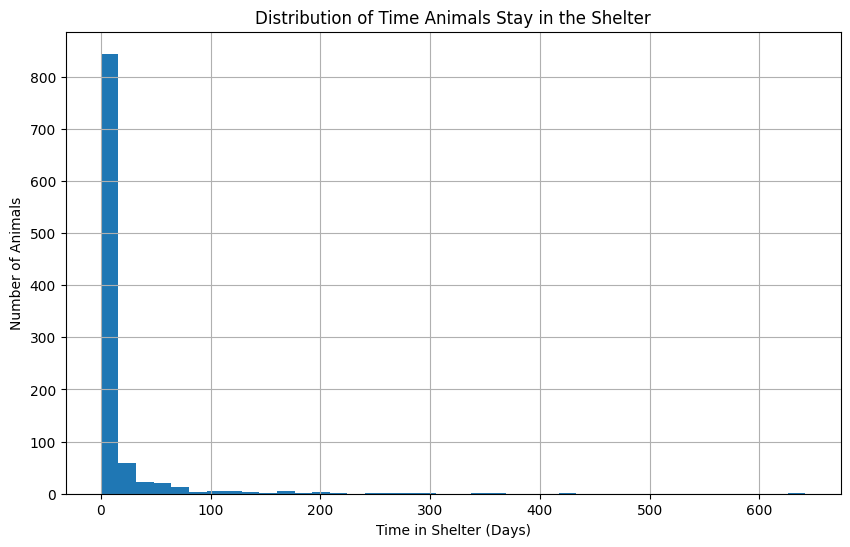

In [23]:
plt.figure(figsize=(10,6))

plt.hist(data["time_in_shelter_days"], bins=40)

plt.xlabel("Time in Shelter (Days)")
plt.ylabel("Number of Animals")
plt.title("Distribution of Time Animals Stay in the Shelter")

plt.grid(True)

plt.show()

Die Grafik zeigt die Verteilung der Aufenthaltsdauer im Tierheim. Ein Histogramm eignet sich gut dafür, da es zeigt, wie häufig bestimmte Aufenthaltsdauern vorkommen. Dadurch kann man erkennen, ob die meisten Tiere nur kurze Zeit im Tierheim bleiben oder ob viele Tiere länger bleiben. 

#### 6. Skalierung eines Features

In [15]:
scaler = StandardScaler()

data["age_scaled"] = scaler.fit_transform(data[["age_upon_intake_(years)"]])

data[["age_upon_intake_(years)", "age_scaled"]].head()

,age_upon_intake_(years),age_scaled
0,10,0.149851
1,7,-0.875497
2,6,-1.217279
3,10,0.149851
4,16,2.200546


Für das Machine-Learning-Modell wurde das Feld age_upon_intake_(years) skaliert. Dabei wurde der StandardScaler aus der sklearn-Bibliothek verwendet. Durch die Skalierung werden die Werte so transformiert, dass sie einen Mittelwert von 0 und eine Standardabweichung von 1 besitzen. Dies ist wichtig, da viele Machine-Learning-Algorithmen besser funktionieren, wenn numerische Variablen ähnliche Größenordnungen haben und keine Variable das Modell dominiert.